<a href="https://colab.research.google.com/github/CMorgadoM/ML-Proyect/blob/main/tarea%20ML%20V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Viendo como integrar colab con github

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
enlace_mat = 'https://raw.githubusercontent.com/CMorgadoM/ML-Proyect/refs/heads/main/student-mat.csv'
df_mat = pd.read_csv(enlace_mat, sep=";")
df_mat['Prueba'] = 1

enlace_por = 'https://raw.githubusercontent.com/CMorgadoM/ML-Proyect/refs/heads/main/student-por.csv'
df_por = pd.read_csv(enlace_por, sep=";")
df_por['Prueba'] = 0

# Defino variable de indicador de prueba, valor 1 es matemarica, valor 0 es portugues

df = pd.concat([df_mat, df_por], ignore_index=True)

print(df_mat.shape)
print(df_por.shape)
print(df.shape)

(395, 34)
(649, 34)
(1044, 34)


In [3]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Prueba'],
      dtype='object')

In [4]:
# Quito las pruebas intermedias y me quedo solo con la nota final (G3), que será la variable dependiente

df = df[['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences','Prueba','G3']]


# Descripción del problema a análizar

La base de datos contiene registros de estudiantes de dos escuelas de portugal, con multiples variables de caracterización de los individuos (sexo, tamaño del grupo familiar, nivel educacional de los padres, tiempo destinado a estudio, etc.) y que se usará para generar un modelo del rendimiento del estudiante. Con objetivo de entender de mejor forma el impacto de cada variables en el resultado final del estudiante y de poder generar un predictor de rendimiento para estudiantes futuros.

Se ocupara regresión lineal regularizada (Lasso) para predecir la nota final de la prueba, identificando las variables relevantes del modelo.

Adicionalmente se utilizara un algoritmo de Random Forest para predecir la probación del estudiantes (entendida aprobación como obtención de una nota superior a 9.5)

# Descripción y Codificación de variables

## Variables de entorno y caracterización

Se observa que la mayor parte de estudiantes pertenece a la escuela GP, tienen familias sobre los 3 integrantes; más de la mitad son mujeres y la mayoría vive en zonas urbanas.

Más del 90% de la muestra vive con padres juntos (T) y solo un 10% tiene padres separados (A).

Además declaran que la principal razón para ingresar a su escuela es la oferta de cursos disponibles.

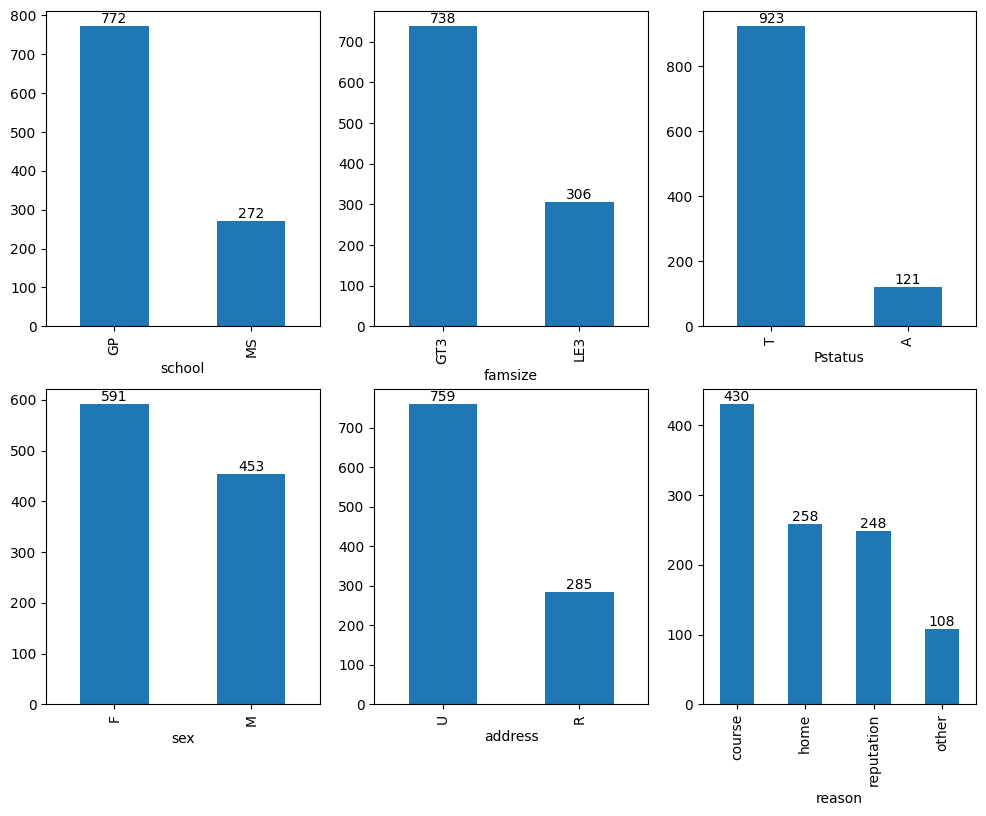

In [30]:
fig,  ax = plt.subplots(2,3, figsize = (12,9))

df['school'].value_counts().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['sex'].value_counts().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['famsize'].value_counts().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['address'].value_counts().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['Pstatus'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['reason'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])
plt.show()

## Caracterización de los padres

Se observa que hay padres y madres de todos los niveles educacionales, destacandose en las madres los niveles "Segundo ciclo" (2) y "Educación superior" (4) y en padres el nivel "Segundo ciclo" (2). Ambos progenitores declaran trabajar mayormente en "otro" tipo de trabajo, fuera de las categorías presentadas. Vale la pena destacar el mayor numero de madres que trabajan en el hogar versus el escaso numero de padres.

En más de 70% se declara a la madre como la cuidadora del estudiante y un 61% de los estudiantes indica que recibe apoyo de su familia para estudiar.

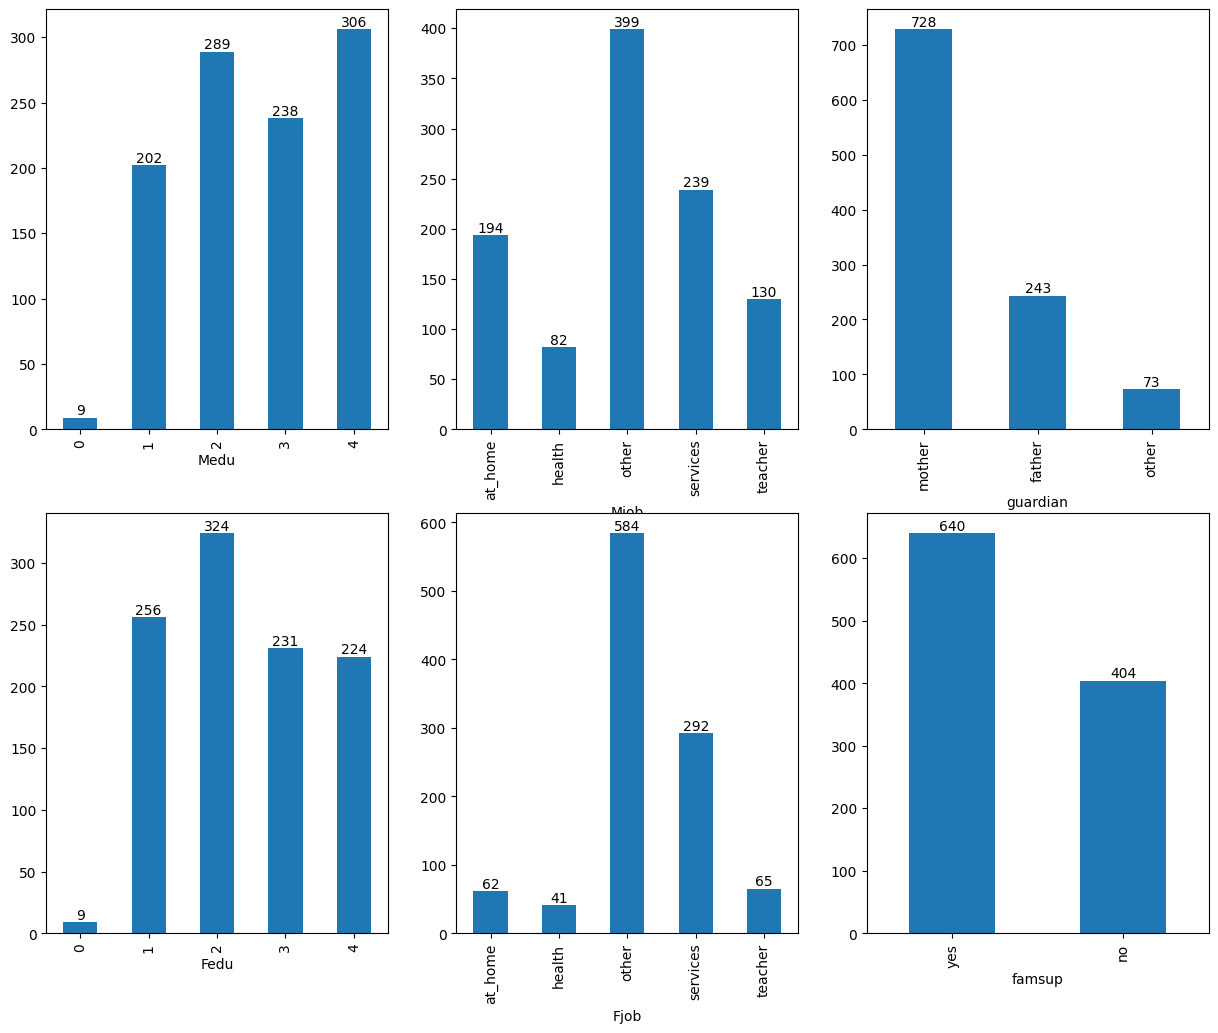

In [35]:
# Caracteristicas de los padres
fig,  ax = plt.subplots(2,3, figsize = (15,12))

df['Medu'].value_counts().sort_index().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['Fedu'].value_counts().sort_index().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['Mjob'].value_counts().sort_index().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['Fjob'].value_counts().sort_index().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['guardian'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['famsup'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])
plt.show()

## Caracterización del estudiante

Se observa que la mayoría de los estudiantes ingresan a la categoría 1 de tiempo de traslado hasta el colegio (menos de 15 minutos) y que mientras mayor el tiempo de traslado menor es el número de estudiantes.

En cuanto a horas de estudio semanal, la mitad de la muestra declara estudiar entre 2 a 5 horas (categoría 2), seguido de una o dos horas a la semana (categoría 1). Se observa tambien que la mayoría ha tenido pocas faltas a clases, con pocos casos extremos que han faltado más de 20 días en total.

La mayoría de estudiantes no ha tenido ramos reprobados, quiere ir a la educación superior, no recib clases pagadas aparte de su colegio y declara no recibir apoyo de su escuela para llevar a cabo sus estudios.

Aproximadamente la mitad de la muestra declara realizar actividades despues de la escuela.


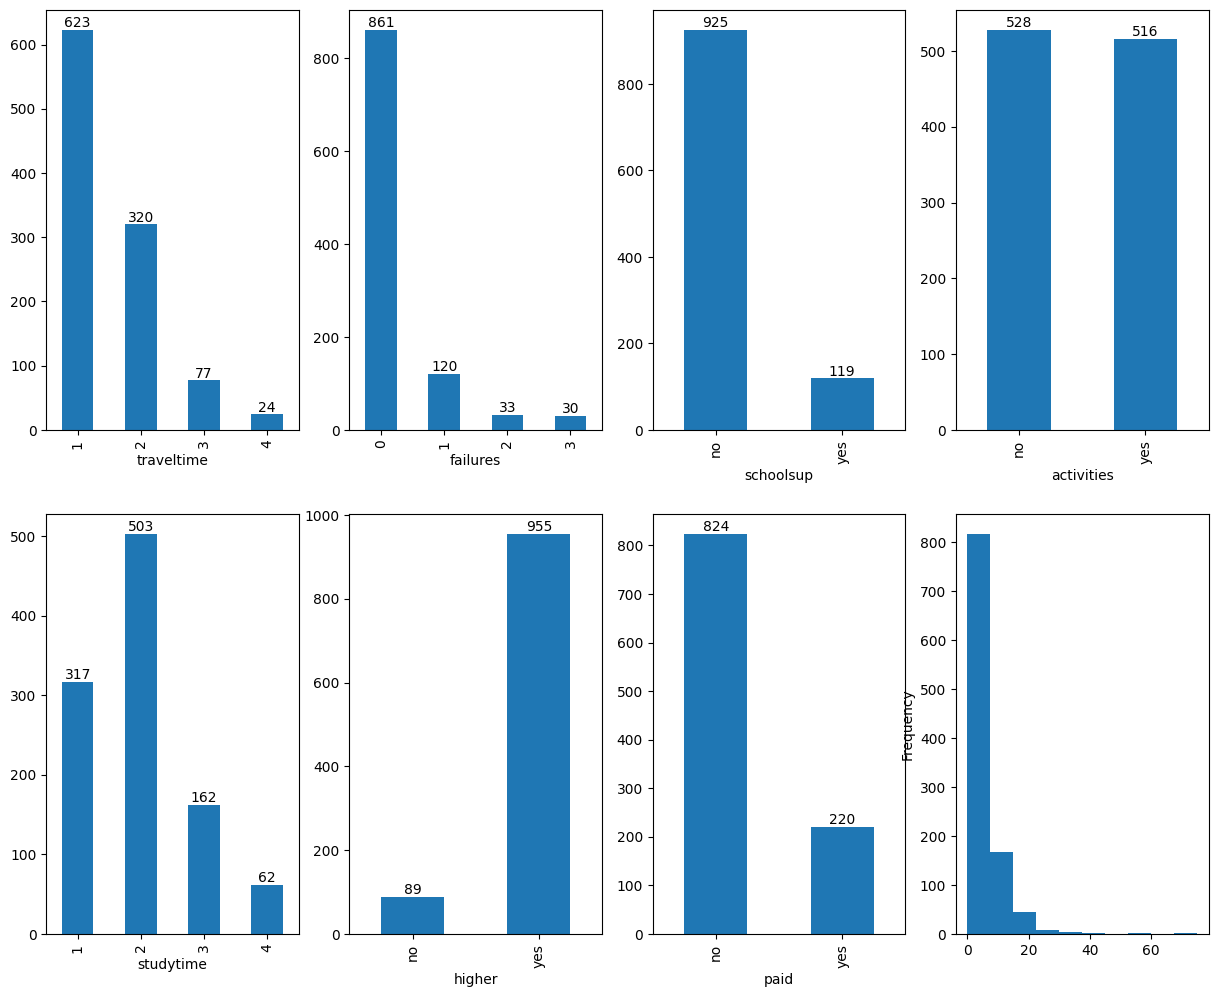

In [40]:
# Caracterización del estudiante
fig,  ax = plt.subplots(2,4, figsize = (15,12))

df['traveltime'].value_counts().sort_index().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['studytime'].value_counts().sort_index().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['failures'].value_counts().sort_index().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['higher'].value_counts().sort_index().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['schoolsup'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['paid'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])

df['activities'].value_counts().plot(kind="bar", ax = ax[0,3])
ax[0,3].bar_label(ax[0,3].containers[0])

df['absences'].plot(kind="hist", ax = ax[1,3])
#ax[1,3].bar_label(ax[1,3].containers[0])

plt.show()

## Variables de salud y bienestar del estudiante



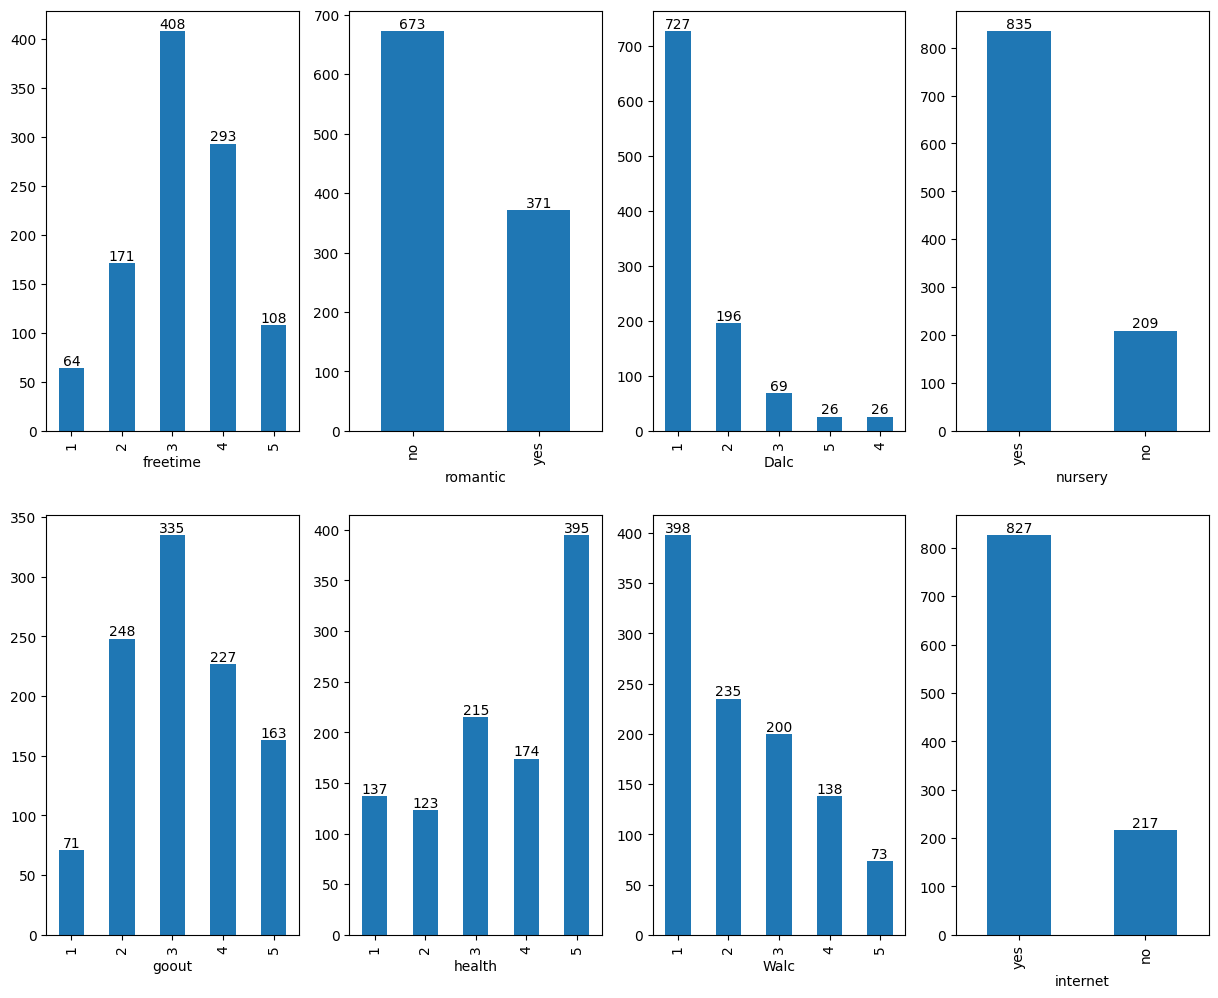

In [41]:
# Caracterización del estudiante
fig,  ax = plt.subplots(2,4, figsize = (15,12))

df['freetime'].value_counts().sort_index().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['goout'].value_counts().sort_index().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['romantic'].value_counts().sort_index().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['health'].value_counts().sort_index().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['Dalc'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['Walc'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])

df['nursery'].value_counts().plot(kind="bar", ax = ax[0,3])
ax[0,3].bar_label(ax[0,3].containers[0])

df['internet'].value_counts().plot(kind="bar", ax = ax[1,3])
ax[1,3].bar_label(ax[1,3].containers[0])


plt.show()

In [37]:
df['school'].value_counts()
df['sex'].value_counts()
df['Dalc'].value_counts()
df['Walc'].value_counts()
#'traveltime',
#    'studytime'
df['traveltime'].value_counts()
#df['health'].value_counts()

,count
traveltime,
1,623
2,320
3,77
4,24


In [5]:
# MYoEdu = [0 if i == 0 else 4 if i == 1 else 9 if i == 2 else 12 if i == 3 else 16 for i in df.Medu] # Convierto la variable a años de educación
# FYoEdu = [0 if i == 0 else 4 if i == 1 else 9 if i == 2 else 12 if i == 3 else 16 for i in df.Fedu] # Convierto la variable a años de educación


# variables tipo likert


# One hot encoding de las variables categoricas
# Variables tipo escala de likert se trabajan como categoricas, para no asumir distnacia lineal entre las categorías
cat_variables = [
    'sex', # Indicador de sexo, valor Femenino=0, masculino=1
    'school', # MS:1 ; GP:0
    'famsize', #  menos de 3(LE3):1 ;  mayor a 3(GT3):0
    'address', # Urbana(U):1 ; Rural(R):0
    'Pstatus', # pades viven juntos(T):1 ; padres viven separados(A):0
    'Medu', # Nivel educacional de la madre; 0-ninguno, 1-primer ciclo, 2-segundo ciclo, 3-secundaria completa, 4-educación superior
    'Fedu', # Nivel educacional de la padre; 0-ninguno, 1-primer ciclo, 2-segundo ciclo, 3-secundaria completa, 4-educación superior
    'Mjob', # Tipo de ocupación de la madre, se deja fuera at_home
    'Fjob', # Tipo de ocupación del padre, se deja fuera at_home
    'reason', # rason para entrar a esta escuela; home= vive cerca de la escuela; reputation=reputacion de la escuela; other=otras razones; course=preferencia por cursos dictados (queda fuera)
    'guardian', # quien cuida al menor, queda fuera padre
    'traveltime',
    'studytime',
    'schoolsup', # recive apoyo escolar
    'famsup', # recibe apoyo familiar
    'paid', # Recibe clases extra en la materia
    'activities', # participa en actividades extracurriculares
    'nursery', # la escuela tiene enfermería
    'higher', # el estudiante aspira a educación superior
    'internet', # internet en casa
    'romantic', # estudiante con relación romantica
    'famrel', # escala likert de calidad de relaciones familiares
    'freetime', # escala likert de cantidad de tiempo libre
    'goout', # Escala likert de salida con amigos
    'Dalc', # Escala likert de Consumo de alcohol en días laborales
    'Walc', # Escala likert de Consumo de alcohol en fin de semana
    'health' # Escala likert de salud general del estudiante
    ]

dummies_df = pd.get_dummies(df, columns=cat_variables, drop_first=True, dtype=int)
dummies_df

,age,failures,absences,Prueba,G3,sex_M,school_MS,famsize_LE3,address_U,Pstatus_T,...,Dalc_4,Dalc_5,Walc_2,Walc_3,Walc_4,Walc_5,health_2,health_3,health_4,health_5
0,18,0,6,1,6,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,17,0,4,1,6,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,0
2,15,3,10,1,10,0,0,1,1,1,...,0,0,0,1,0,0,0,1,0,0
3,15,0,2,1,15,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
4,16,0,4,1,10,0,0,0,1,1,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,19,1,4,0,10,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,1
1040,18,0,4,0,16,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1041,18,0,6,0,9,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,1
1042,17,0,6,0,10,1,1,1,1,1,...,0,0,0,0,1,0,1,0,0,0


# Ejecución Lasso

In [ ]:
# Cargo paquetes para lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [ ]:
X = dummies_df.drop('G3', axis=1)
y = dummies_df[['G3']]
print(X.head())
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

   age  failures  absences  Prueba  sex_M  school_MS  famsize_LE3  address_U  \
0   18         0         6       1      0          0            0          1   
1   17         0         4       1      0          0            0          1   
2   15         3        10       1      0          0            1          1   
3   15         0         2       1      0          0            0          1   
4   16         0         4       1      0          0            0          1   

   Pstatus_T  Medu_1  ...  Dalc_4  Dalc_5  Walc_2  Walc_3  Walc_4  Walc_5  \
0          0       0  ...       0       0       0       0       0       0   
1          1       1  ...       0       0       0       0       0       0   
2          1       1  ...       0       0       0       1       0       0   
3          1       0  ...       0       0       0       0       0       0   
4          1       0  ...       0       0       1       0       0       0   

   health_2  health_3  health_4  health_5  
0         0 

In [ ]:
# implementamos lasso
l1_model = Lasso(alpha = 0.04)
l1_model.fit(X_train, y_train)

y_hat = l1_model.predict(X_test)
r2_score(y_test, y_hat)

0.3000685286437247

In [ ]:

param_vals = []
r2_vals = []

for alpha_val in np.linspace(0, 20, num=1000):
  l1_iter_model = Lasso(alpha = alpha_val)
  l1_iter_model.fit(X_train, y_train)
  y_hat = l1_iter_model.predict(X_test)
  param_vals.append(alpha_val)
  r2_vals.append(r2_score(y_test, y_hat))

max_r2 = np.argmax(r2_vals)
print(f'El mayor r2 encontrado es {r2_vals[max_r2]}, con un parametro alpha = {param_vals[max_r2]}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.369e+03, tolerance: 1.324e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

El mayor r2 encontrado es 0.30006708278559036, con un parametro alpha = 0.04004004004004004


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
y_train_class = [1 if i >= 10 else 0 for i in y_train.G3]
y_test_class = [1 if i >= 10 else 0 for i in y_test.G3]

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=500, max_depth=25)
rf_reg.fit(X_train, y_train_class)


RandomForestRegressor(max_depth=25, n_estimators=500)

In [ ]:
r2_score(y_test, rf_reg.predict(X_test))

-10.364590549153824

In [ ]:
rf_clas = RandomForestClassifier(n_estimators=500, max_depth=25)
rf_clas.fit(X_train, y_train_class)

RandomForestClassifier(max_depth=25, n_estimators=500)

In [ ]:
accuracy_score(y_test_class, rf_clas.predict(X_test))

0.84688995215311